<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Procesamiento de Lenguaje Natural**
## **Desafio, Traductor**

### Consigna

* Replicar el modelo traductor desarrollado en clase (https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/blob/may_2026/Clase%206/C%C3%B3digo/Traductor.ipynb) y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros (por ejemplo, el número de unidades en las capas LSTM) y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes, comparando el desempeño de distintas configuraciones del modelo.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

### Actividades opcionales

* Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.
* Experimentar con diferentes estrategias de generación de secuencias, como muestreo aleatorio (sampling) o búsqueda por haz (beam search).
* Implementar y entrenar una versión equivalente del modelo utilizando PyTorch, comparando los resultados con la implementación original.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model
import pickle
import os
import sys, glob
import matplotlib.pyplot as plt
import seaborn as sns
import time


I0000 00:00:1782088554.767700 2471842 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782088554.792169 2471842 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782088555.502572 2471842 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Construct the path to the nvidia packages within the virtual environment
site_packages = os.path.join(sys.prefix, 'lib', f'python{sys.version_info.major}.{sys.version_info.minor}', 'site-packages')
nvidia_base_path = os.path.join(site_packages, 'nvidia')
# Find all 'lib' directories inside the nvidia package and add them to LD_LIBRARY_PATH
nvidia_lib_dirs = glob.glob(os.path.join(nvidia_base_path, '*', 'lib'))
if nvidia_lib_dirs:
    os.environ['LD_LIBRARY_PATH'] = ':'.join(nvidia_lib_dirs) + ':' + os.environ.get('LD_LIBRARY_PATH', '')


Definimos primero las funciones que vamos a necesitar en el proceso. Modifique las funciones provistas en el notebook `Traductor.ipynb` principalmente dando documentación via docstrings y comentarios. Esta documentación la cree con LLMs, aprovechando este desafío para probar el uso de LLMs locales, por ello se tiene tanto detalle. Si es de utilidad para la materia, son libres de tomarlas y aplicarlas en las notebooks. Si quieren replicar lo hecho, se hizo tomando cada función y con el prompt `Documenta esta función utilizando docstrings y comentarios`.

In [3]:
# Definimos una función para crear un dataset de TensorFlow a partir de las secuencias de entrada y salida
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes, max_input_len, max_out_len):
    """
    Crea un dataset de TensorFlow a partir de las secuencias de entrada y salida.

    Args:
        enc_seqs (list of list of int): Lista de secuencias de entrada.
        dec_in_seqs (list of list of int): Lista de secuencias de entrada para el decoder, con un token de inicio.
        dec_out_seqs (list of list of int): Lista de secuencias de salida para el decoder, con un token de fin.
        batch_size (int): Tamaño del lote para el dataset.
        num_classes (int): Número total de clases o tokens únicos en el vocabulario.

    Returns:
        tf.data.Dataset: Dataset de TensorFlow que proporciona tuplas de entrada y salida,
                         donde la entrada es una tupla de secuencias de encoder y decoder (con inicio),
                         y la salida es la secuencia one-hot del decoder.
    """
    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes)  # shape (max_out_len, num_classes)
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,), dtype=tf.int32),
        ),
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


In [4]:
# Definimos una función para verificar si un archivo es un pickle válido, evitando errores al cargar modelos o datos
def _is_valid_pickle(path):
    """
    Verifica si el archivo en la ruta dada es un pickle válido.
    Args:
        path (str): Ruta del archivo a verificar.

    Returns:
        bool: True si el archivo parece ser un pickle válido, False en caso contrario.
    """
    try:
        with open(path, "rb") as f:
            head = f.read(20)
        return b"<html" not in head.lower() and b"<!doctype" not in head.lower()
    except Exception:
        return False

# Función para cargar los embeddings de GloVe desde un archivo pickle, devolviendo un diccionario de palabras a índices y la matriz de embeddings
def load_glove_embeddings(pkl_path):
    """
    Carga el pickle de GloVe y devuelve un diccionario de palabras a índices y la matriz de embeddings.

    Args:
        pkl_path (str): Ruta del archivo pickle que contiene los embeddings de GloVe.

    Returns:
        tuple: Un par ordenado formado por una matriz de embeddings y un diccionario mapeando palabras a índices.
    """
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz = os.path.getsize(pkl_path)
    with open(pkl_path, "rb") as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    idx_array = np.arange(embeddings.shape[0])
    word2idx = dict(zip(embeddings["word"], idx_array))
    return embeddings, word2idx

# Función para obtener el embedding de una palabra dada su representación en el diccionario de embeddings, devolviendo un vector de ceros si la palabra no se encuentra
def get_word_embedding(word, embeddings, word2idx, n_features=50):
    """
    Obtiene el embedding de una palabra específica a partir del conjunto de embeddings.

    Args:
        word (str): Palabra para la cual se desea obtener el embedding.
        embeddings (np.ndarray): Matriz que contiene los embeddings.
        word2idx (dict): Diccionario mapeando palabras a índices en la matriz de embeddings.
        n_features (int, optional): Dimensión del vector de características. Por defecto es 50.

    Returns:
        np.ndarray: Vector de embedding para la palabra especificada o un vector de ceros si no se encuentra.
    """
    i = word2idx.get(word, -1)
    return embeddings[i]["embedding"] if i != -1 else np.zeros(n_features)

# Función para construir la matriz de embeddings para el vocabulario de entrada, utilizando los embeddings de GloVe y devolviendo una matriz donde cada fila corresponde al embedding de una palabra en el vocabulario
def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove, nb_words, embed_dim=50):
    """
    Construye la matriz de embeddings para un conjunto de palabras dado utilizando los embeddings de GloVe.

    Args:
        word2idx_inputs (dict): Diccionario mapeando las palabras del vocabulario a índices.
        embeddings (np.ndarray): Matriz que contiene los embeddings de GloVe.
        word2idx_glove (dict): Diccionario mapeando las palabras en el conjunto de embeddings de GloVe a sus respectivos índices.
        nb_words (int): Número total de palabras para las cuales se construirá la matriz de embeddings.
        embed_dim (int, optional): Dimensión del vector de características. Por defecto es 50.

    Returns:
        np.ndarray: Matriz de embeddings donde cada fila corresponde al embedding de una palabra en el vocabulario.
    """
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix

In [5]:
# Función para construir el modelo en codificación (Encoder)
def build_encoder(nb_words, embed_dim, embedding_matrix, max_input_len, n_units):
    """
    Construye el modelo de la parte del encoder.

    :param nb_words: El número total de palabras en el vocabulario.
    :type nb_words: int

    :param embed_dim: La dimensión del vector de incrustación.
    :type embed_dim: int

    :param embedding_matrix: Matriz de pre-entrenamiento para la capa de incrustación.
    :type embedding_matrix: numpy.ndarray

    :param max_input_len: La longitud máxima de las secuencias de entrada.
    :type max_input_len: int

    :param n_units: El número de unidades en la LSTM del encoder.
    :type n_units: int

    :return: Una tupla que contiene los inputs del encoder, estados ocultos y de celda,
             así como las capas de incrustación y LSTM del encoder.
    :rtype: tuple
    """

    enc_inputs = Input(shape=(max_input_len,), name="encoder_inputs")

    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix],
        trainable=False,
        name="encoder_embedding",
    )
    enc_emb = Dropout(0.3, name="encoder_dropout")(enc_emb_layer(enc_inputs))

    enc_lstm_layer = LSTM(n_units, return_state=True, name="encoder_lstm")
    _, state_h, state_c = enc_lstm_layer(enc_emb)

    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer


# Función para construir el modelo en decodificación (Decoder)
def build_decoder(num_words_output, max_out_len, n_units, encoder_states):
    """
    Construye el modelo de la parte del decoder.

    :param num_words_output: El número total de palabras en el vocabulario de salida.
    :type num_words_output: int

    :param max_out_len: La longitud máxima de las secuencias de salida.
    :type max_out_len: int

    :param n_units: El número de unidades en la LSTM del decoder.
    :type n_units: int

    :param encoder_states: Los estados ocultos y de celda del encoder para ser usados como el estado inicial del decoder.
    :type encoder_states: list

    :return: Una tupla que contiene los inputs del decoder, la salida del decoder,
             así como las capas de incrustación, LSTM y Dense del decoder.
    :rtype: tuple
    """

    dec_inputs = Input(shape=(max_out_len,), name="decoder_inputs")

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        input_length=max_out_len,
        name="decoder_embedding",
    )
    dec_emb = Dropout(0.3, name="decoder_dropout")(dec_emb_layer(dec_inputs))

    dec_lstm_layer = LSTM(
        n_units, return_sequences=True, return_state=True, name="decoder_lstm"
    )
    dec_out, _, _ = dec_lstm_layer(dec_emb, initial_state=encoder_states)

    dec_dense_layer = Dense(
        num_words_output, activation="softmax", name="decoder_dense"
    )
    dec_out = dec_dense_layer(dec_out)

    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer

In [6]:
# Función para construir el modelo de inferencia del encoder, que solo devuelve los estados ocultos y de celda después de procesar la secuencia de entrada
def build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units):

    """
    Construye un modelo de inferencia para el encoder.

    Este modelo recibe una secuencia de entrada y devuelve solo los estados ocultos y de celda del LSTM,
    que son necesarios para inicializar el decoder durante la inferencia.

    Args:
        enc_inputs (Input): Capa de entrada para el modelo.
        enc_emb_layer (Embedding): Capa de embedding preentrenada para convertir índices de tokens en vectores densos.
        enc_lstm_layer (LSTM): Capa LSTM que procesa los embeddings y devuelve sus estados ocultos y de celda.
        n_units (int): Número de unidades en la capa LSTM.

    Returns:
        Model: Modelo de Keras con una entrada y dos salidas correspondientes a los estados h y c del encoder.
    """
    enc_emb = enc_emb_layer(enc_inputs)  # reutiliza pesos entrenados
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return Model(enc_inputs, [state_h, state_c])


# Función para construir el modelo de inferencia del decoder, que solo devuelve la secuencia de salida completa después de procesar una secuencia de entrada inicial
def build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units):

    """
    Construye un modelo de inferencia paso a paso para el decoder.

    Este modelo recibe un token de entrada individual junto con los estados ocultos y de celda del encoder,
    y genera la siguiente predicción en la secuencia. Se utiliza iterativamente durante la inferencia para
    generar tokens sucesivos hasta alcanzar un token final o un límite de longitud.

    Args:
        dec_emb_layer (Embedding): Capa de embedding preentrenada para convertir índices de tokens en vectores densos.
        dec_lstm_layer (LSTM): Capa LSTM que procesa los embeddings y devuelve sus estados ocultos, de celda y la salida.
        dec_dense_layer (Dense): Capa densa que genera las probabilidades de los tokens de salida.
        n_units (int): Número de unidades en la capa LSTM.

    Returns:
        Model: Modelo de Keras con tres entradas correspondientes al token de entrada, el estado h y el estado c del encoder,
            y tres salidas correspondientes a la probabilidad del token siguiente, el nuevo estado h y el nuevo estado c.
    """
    dec_input_single = Input(shape=(1,), name="dec_input_single")
    dec_state_h_in = Input(shape=(n_units,), name="dec_state_h")
    dec_state_c_in = Input(shape=(n_units,), name="dec_state_c")

    dec_emb_single = dec_emb_layer(dec_input_single)  # reutiliza pesos entrenados
    dec_out, h_out, c_out = dec_lstm_layer(
        dec_emb_single, initial_state=[dec_state_h_in, dec_state_c_in]
    )
    dec_out = dec_dense_layer(dec_out)

    return Model(
        [dec_input_single, dec_state_h_in, dec_state_c_in], [dec_out, h_out, c_out]
    )

In [34]:
# Definimos funciones para traducir una secuencia de entrada utilizando los modelos de inferencia del encoder y decoder, implementando un proceso de búsqueda codiciosa (greedy search) para generar la secuencia de salida token por token
def translate_sentence(input_seq, encoder_model, decoder_model, word2idx_outputs, idx2word_target, max_out_len):
    h, c = encoder_model.predict(input_seq, verbose=0)  # desempaqueta directo
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs["<sos>"]
    eos = word2idx_outputs["<eos>"]

    output_sentence = []
    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict(
            [target_seq, h, c],
            verbose=0,  # estados como args separados
        )
        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target[idx])
        target_seq[0, 0] = idx

    return " ".join(output_sentence)


def translate(text, input_tokenizer, max_input_len, encoder_model, decoder_model, word2idx_outputs, idx2word_target, max_out_len):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence(seq, encoder_model, decoder_model, word2idx_outputs, idx2word_target, max_out_len)

In [31]:
def download_data(MAX_NUM_SENTENCES=50000):
    """
    Downloads and preprocesses a dataset of English-Spanish sentence pairs.

    This function downloads the English-Spanish translation dataset from TensorFlow's storage,
    unzips it, and reads in sentences up to a maximum number specified. Sentences are shuffled
    for randomness and then split into input (English) and output (Spanish) lists with special tokens
    added at the beginning and end of the output sentences.

    Parameters:
        MAX_NUM_SENTENCES (int): The maximum number of sentence pairs to load from the dataset.

    Returns:
        tuple: A tuple containing three lists:
            - input_sentences (list of str): English sentences for translation input.
            - output_sentences (list of str): Spanish sentences with an end-of-sentence token added.
            - output_sentences_inputs (list of str): Spanish sentences prefixed with a start-of-sequence token.
    """

    # Descargamos el datset de traducción inglés-español
    if not os.path.exists("spa-eng"):
        os.system(
            "curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
        )
        os.system("unzip -q spa-eng.zip")

    with open("./spa-eng/spa.txt") as f:
        lines = f.read().split("\n")[:-1]

    np.random.seed(40)
    np.random.shuffle(lines)

    # Cargamos los datos
    input_sentences, output_sentences, output_sentences_inputs = [], [], []

    for i, line in enumerate(lines):
        if i >= MAX_NUM_SENTENCES:
            break
        if "\t" not in line:
            continue
        input_sentence, output = line.rstrip().split("\t")[:2]
        output_sentences.append(output + " <eos>")
        output_sentences_inputs.append("<sos> " + output)
        input_sentences.append(input_sentence)

    print(f"Oraciones cargadas: {len(input_sentences)}")

    return input_sentences, output_sentences, output_sentences_inputs

def tokenizer(MAX_VOCAB_SIZE=16000, max_input_len=32, max_out_len=32,
              input_sentences=None, output_sentences=None, output_sentences_inputs=None):
    """
    Tokenizes and pads the English-Spanish sentence pairs for translation.

    This function tokenizes the input (English) and output (Spanish) sentences using
    Keras' Tokenizer class. It also converts the sentences into sequences of integers,
    fits a tokenizer on these sequences, and pads them to ensure uniform sequence lengths.

    Parameters:
        MAX_VOCAB_SIZE (int): The maximum number of words in each vocabulary.
        max_input_len (int): Maximum length for input sequences.
        max_out_len (int): Maximum length for output sequences.
        input_sentences (list of str): List of English sentences to be tokenized and padded.
        output_sentences (list of str): List of Spanish sentences with end-of-sentence tokens.
        output_sentences_inputs (list of str): List of Spanish sentences prefixed with start-of-sequence tokens.

    Returns:
        tuple: A tuple containing the following elements:
            - num_words_output (int): The number of words in the Spanish vocabulary, not exceeding MAX_VOCAB_SIZE.
            - encoder_input_sequences (numpy.ndarray): 2D array of padded sequences of tokenized English sentences.
            - decoder_input_sequences (numpy.ndarray): 2D array of padded sequences of tokenized Spanish input sentences.
            - decoder_output_sequences (numpy.ndarray): 2D array of padded sequences of tokenized Spanish output sentences.
            - word2idx_inputs (dict): A dictionary mapping each unique English word to its index in the vocabulary.
            - word2idx_outputs (dict): A dictionary mapping each unique Spanish word to its index in the vocabulary.

    Note:
        The tokenizer for the output sequences includes special tokens '<sos>' and '<eos>'.
    """

    # Tokenizamos las oraciones de entrada y salida

    input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
    input_tokenizer.fit_on_texts(input_sentences)
    input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
    word2idx_inputs = input_tokenizer.word_index

    # Solo se tomarán en cuenta las palabras más frecuentes y se eliminan signos de puntuación
    output_tokenizer = Tokenizer(
        num_words=MAX_VOCAB_SIZE, filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
    )

    output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
    output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
    output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
    word2idx_outputs = output_tokenizer.word_index

    num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)

    print(f"Vocabulario EN: {len(word2idx_inputs)} | ES: {len(word2idx_outputs)}")
    print(f"max_input_len={max_input_len}  max_out_len={max_out_len}")

    # Rellenamos las secuencias con ceros para que tengan la misma longitud
    encoder_input_sequences = pad_sequences(input_integer_seq, maxlen=max_input_len)
    decoder_input_sequences = pad_sequences(
        output_input_integer_seq, maxlen=max_out_len, padding="post"
    )
    decoder_output_sequences = pad_sequences(
        output_integer_seq, maxlen=max_out_len, padding="post"
    )

    return num_words_output, encoder_input_sequences, decoder_input_sequences, \
           decoder_output_sequences, word2idx_inputs, word2idx_outputs, input_tokenizer

def train_test_split(BATCH_SIZE, val_split, encoder_input_sequences, decoder_input_sequences, decoder_output_sequences, num_words_output):
    """
    Splits the dataset into training and validation sets.

    This function splits the provided sequences of tokenized English and Spanish sentences
    into training and validation datasets using a specified split ratio. It also creates
    TensorFlow datasets from these sequences for batching purposes.

    Parameters:
        BATCH_SIZE (int): The number of samples per batch.
        val_split (float): Fraction of data to reserve for validation (0 < val_split < 1).
        encoder_input_sequences (numpy.ndarray): 2D array of padded sequences of tokenized English sentences.
        decoder_input_sequences (numpy.ndarray): 2D array of padded sequences of tokenized Spanish input sentences.
        decoder_output_sequences (numpy.ndarray): 2D array of padded sequences of tokenized Spanish output sentences.
        num_words_output (int): The number of words in the Spanish vocabulary, not exceeding MAX_VOCAB_SIZE.

    Returns:
        tuple: A tuple containing two TensorFlow datasets:
            - train_ds (tf.data.Dataset): Training dataset with batches of encoder and decoder input/output sequences.
            - val_ds (tf.data.Dataset): Validation dataset with batches of encoder and decoder input/output sequences.
    """

    # Calculate the split index for training and validation sets
    split_idx = int(len(encoder_input_sequences) * (1 - val_split))

    # Create TensorFlow datasets for training and validation
    train_ds = make_dataset(
        encoder_input_sequences[:split_idx],
        decoder_input_sequences[:split_idx],
        decoder_output_sequences[:split_idx],
        BATCH_SIZE,
        num_words_output,
        encoder_input_sequences.shape[1],
        decoder_input_sequences.shape[1]
    )
    val_ds = make_dataset(
        encoder_input_sequences[split_idx:],
        decoder_input_sequences[split_idx:],
        decoder_output_sequences[split_idx:],
        BATCH_SIZE,
        num_words_output,
        encoder_input_sequences.shape[1],
        decoder_input_sequences.shape[1]
    )
    
    return train_ds, val_ds


def make_embeddings(MAX_VOCAB_SIZE, word2idx_inputs):
    """
    Creates an embedding matrix for the input vocabulary using GloVe embeddings.

    This function downloads a pre-trained GloVe embedding file if it is not already available
    locally. It then constructs an embedding matrix for the English vocabulary based on these embeddings.
    Words in the input vocabulary that do not have a corresponding GloVe embedding are assigned zero vectors.

    Parameters:
        MAX_VOCAB_SIZE (int): The maximum number of words to consider in the vocabulary.
        word2idx_inputs (dict): A dictionary mapping each unique English word to its index in the vocabulary.

    Returns:
        numpy.ndarray: A 2D array where each row corresponds to the embedding vector for a word
                       in the input vocabulary. Words not found in GloVe have zero vectors as their embeddings.
    """

    # Definimos la ruta del archivo pickle de GloVe y el ID del archivo en Google Drive para descargarlo si no está disponible localmente
    _PKL_PATH = "gloveembedding.pkl"
    _FILE_ID = "1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94"

    # Check if the file exists and is a valid pickle file; otherwise, download it
    if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
        print("Descargando gloveembedding.pkl desde Google Drive...")
        if os.path.exists(_PKL_PATH):
            os.remove(_PKL_PATH)
        try:

            gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
        except Exception:
            os.system(
                f"curl -L -o {_PKL_PATH} "
                f"'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'"
            )
        if not _is_valid_pickle(_PKL_PATH):
            raise ValueError("El archivo descargado no es un pickle válido.")
        print("Descarga completada.")
    else:
        print("gloveembedding.pkl ya disponible.")



    # Define embedding dimension and the number of words to consider
    EMBED_DIM = 50
    nb_words = min(MAX_VOCAB_SIZE, len(word2idx_inputs))

    # Load GloVe embeddings and build the embedding matrix for the input vocabulary
    glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
    embedding_matrix = build_embedding_matrix(
        word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
    )
    print(f"Embeddings nulos: {np.sum(np.sum(embedding_matrix**2, axis=1) == 0)}")

    return nb_words, embedding_matrix


In [9]:
def compile_and_fit_model(n_units, nb_words, EMBED_DIM, embedding_matrix, max_input_len, num_words_output, max_out_len, train_ds, val_ds, epochs, return_enc_dec=False):
    # Construimos los modelos de encoder y decoder utilizando las funciones definidas anteriormente
    enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
        nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units
    )
    dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
        num_words_output, max_out_len, n_units, enc_states
    )

    # Definimos el modelo completo que incluye la capa de embedding y la capa LSTM del encoder
    model = Model([enc_inputs, dec_inputs], dec_outputs)

    # Definimos los callbacks para reducir la tasa de aprendizaje cuando la validación no mejore y para detener el entrenamiento temprano si no hay mejora en la validación
    lr_scheduler = ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1
    )
    early_stop = EarlyStopping(
        monitor="val_loss", patience=4, restore_best_weights=True, verbose=1
    )

    # Compilamos el modelo con la función de pérdida, los optimizadores y los callbacks
    model.compile(
        loss="categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        metrics=["accuracy"],
    )


    # Entrenamos el modelo y medimos el tiempo de entrenamiento
    start_time = time.time()
    hist = model.fit(
        train_ds, validation_data=val_ds, epochs=epochs, callbacks=[lr_scheduler, early_stop]
    )
    end_time = time.time()

    time_taken = end_time - start_time

    # After training, create encoder and decoder models for inference when needed
    if return_enc_dec:
        # # Create encoder model
        # encoder_model = Model(enc_inputs, enc_states)
        
        # # Create decoder model with inputs that include the initial states
        # dec_infer_inputs = [
        #     Input(batch_shape=(None, 1), name="decoder_input"),
        #     Input(shape=(n_units,), name="h_initial"),
        #     Input(shape=(n_units,), name="c_initial")
        # ]
        # dec_emb_infer = dec_emb_layer(dec_infer_inputs[0])
        # dec_lstm_out_infer, h_state_infer, c_state_infer = dec_lstm_layer(
        #     dec_emb_infer,
        #     initial_state=[dec_infer_inputs[1], dec_infer_inputs[2]]
        # )
        # dec_out_infer = dec_dense_layer(dec_lstm_out_infer)
        
        # decoder_model = Model([dec_infer_inputs[0], dec_infer_inputs[1], dec_infer_inputs[2]], 
        #                     [dec_out_infer, h_state_infer, c_state_infer])
        encoder_model = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units)
        decoder_model = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units)
        
        # Return main model along with inference models
        return model, encoder_model, decoder_model, hist, time_taken
    
    # If not returning enc/dec, just return main model and training artifacts
    return model, hist, time_taken

def plot_single_model(hist):
    # Graficamos la pérdida y la precisión durante el entrenamiento
    epoch_count = range(1, len(hist.history["accuracy"]) + 1)
    sns.lineplot(x=epoch_count, y=hist.history["accuracy"], label="train")
    sns.lineplot(x=epoch_count, y=hist.history["val_accuracy"], label="valid")

    plt.title("Accuracy durante entrenamiento")
    plt.xlabel("Época")
    plt.ylabel("Precisión")
    plt.legend(title="Dataset")
    plt.grid(True)
    plt.show()

def plot_multiple_models(histories, labels):
    # Graficamos la pérdida y la precisión durante el entrenamiento para múltiples modelos
    epoch_count = range(1, len(histories[0].history["accuracy"]) + 1)
    colors = sns.color_palette("tab10", n_colors=len(histories))
    for hist, label in zip(histories, labels):
        sns.lineplot(x=epoch_count, y=hist.history["accuracy"], label=f"{label} train", color=colors[histories.index(hist)])
        sns.lineplot(x=epoch_count, y=hist.history["val_accuracy"], label=f"{label} valid", linestyle="--", color=colors[histories.index(hist)])

    plt.title("Accuracy durante entrenamiento")
    plt.xlabel("Época")
    plt.ylabel("Precisión")
    plt.legend(title="Modelo")
    plt.grid(True)
    plt.show()

In [14]:
def build_model(MAX_NUM_SENTENCES=20000, MAX_VOCAB_SIZE=16000, max_input_len=32, max_out_len=32, BATCH_SIZE=64, val_split=0.2, n_units=256, EMBED_DIM=50, epochs=30, plot=True):
    input_sentences, output_sentences, output_sentences_inputs = download_data(MAX_NUM_SENTENCES=MAX_NUM_SENTENCES)
    num_words_output, encoder_input_sequences, decoder_input_sequences, \
    decoder_output_sequences, word2idx_inputs, word2idx_outputs = tokenizer(
        MAX_VOCAB_SIZE=MAX_VOCAB_SIZE,
        max_input_len=max_input_len,
        max_out_len=max_out_len,
        input_sentences=input_sentences,
        output_sentences=output_sentences,
        output_sentences_inputs=output_sentences_inputs,    
    )
    nb_words, embedding_matrix = make_embeddings(MAX_VOCAB_SIZE, word2idx_inputs)
    train_ds, val_ds = train_test_split(BATCH_SIZE, val_split, encoder_input_sequences, decoder_input_sequences, decoder_output_sequences, num_words_output)
    model, hist, time_taken = compile_and_fit_model(n_units, nb_words, EMBED_DIM, embedding_matrix, max_input_len, num_words_output, max_out_len, train_ds, val_ds, epochs)
    if plot:
        plot_single_model(hist)
    return model, hist, time_taken


In [11]:
# Comparo el efecto de un conjunto de datos más aplios variando MAX_NUM_SENTENCES y MAX_VOCAB_SIZE
histories_vocab = []
labels_vocab = []
time_taken_list_vocab = []
max_vocab_list = [8000, 16000, 32000]
max_sentences_list = [max_vocab * 1.25 for max_vocab in max_vocab_list]
for max_sentences, max_vocab in zip(max_sentences_list, max_vocab_list):
    print(f"Entrenando modelo con MAX_NUM_SENTENCES={max_sentences} y MAX_VOCAB_SIZE={max_vocab}...")
    model, hist, time_taken = build_model(MAX_NUM_SENTENCES=max_sentences, MAX_VOCAB_SIZE=max_vocab, epochs=30, plot=False)
    histories_vocab.append(hist)
    labels_vocab.append(f"{max_sentences} sent, {max_vocab} vocab")
    time_taken_list_vocab.append(time_taken)

Entrenando modelo con MAX_NUM_SENTENCES=10000.0 y MAX_VOCAB_SIZE=8000...
Oraciones cargadas: 10000
Vocabulario EN: 4977 | ES: 7803
max_input_len=32  max_out_len=32
gloveembedding.pkl ya disponible.
Embeddings nulos: 212


I0000 00:00:1782088559.585377 2471842 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 19931 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/jiteich/repos/ceia/pln1/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30


I0000 00:00:1782088560.103971 2471842 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


      1/Unknown 2s 2s/step - accuracy: 0.0000e+00 - loss: 8.9615

...

I0000 00:00:1782089655.469070 2478142 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3173365102329996053
I0000 00:00:1782089655.469088 2478142 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 4569380834600027145
I0000 00:00:1782089655.469092 2478142 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 1989180100818665696
I0000 00:00:1782089655.469094 2478142 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 11356862021292535026
I0000 00:00:1782089655.469097 2478142 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3061796174163642220


499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9202 - loss: 0.3494

I0000 00:00:1782089676.643126 2477965 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 11797339800094310461
I0000 00:00:1782089676.643145 2477965 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 9193475964318917573
I0000 00:00:1782089676.643148 2477965 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 18290802461504515207
I0000 00:00:1782089676.643152 2477965 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 14732368380969189672
I0000 00:00:1782089676.643155 2477965 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3309757049768029226



Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.9206 - loss: 0.3469 - val_accuracy: 0.8809 - val_loss: 0.7619 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 28.


I0000 00:00:1782089680.903312 2478142 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 1989180100818665696
I0000 00:00:1782089680.903329 2478142 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 11356862021292535026
I0000 00:00:1782089680.903312 2472001 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 4569380834600027145
I0000 00:00:1782089680.903331 2478142 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3061796174163642220


Análisis del efecto del tamaño del vocabulario:


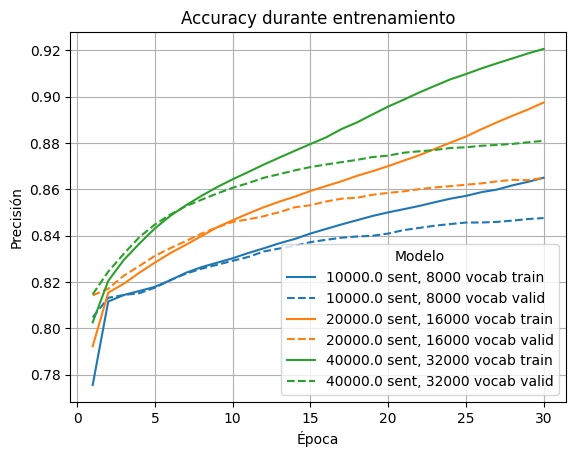

Tiempos de entrenamiento:
10000.0 sent, 8000 vocab: 100.66 segundos
20000.0 sent, 16000 vocab: 269.70 segundos
40000.0 sent, 32000 vocab: 748.15 segundos


In [12]:
print("Análisis del efecto del tamaño del vocabulario:")
plot_multiple_models(histories_vocab, labels_vocab)
print("Tiempos de entrenamiento:")
for label, time_taken in zip(labels_vocab, time_taken_list_vocab):
    print(f"{label}: {time_taken:.2f} segundos")

Observamos que al aumentar la cantidad de oraciones y el tamaño del vocabulario, la precisión aumenta considerablemente, aunque así también el tiempo de cómputo. La diferencia entre el segundo caso y el tercero no resulta lo suficientemente grande como para justificar el elevado aumento del costo computacional, definiendo utilizar 50.000 oraciones y un vocabulario de 16.000 palabras.

In [15]:
# Comparo el efecto de secuencias de mayor longitud variando max_input_len y max_out_len
histories_lens = []
labels_lens = []
time_taken_list_lens = []
for max_input_len, max_out_len in [(20, 20), (32, 32), (64,64)]:
    print(f"Entrenando modelo con max_input_len={max_input_len} y max_out_len={max_out_len}...")
    model, hist, time_taken = build_model(max_input_len=max_input_len, max_out_len=max_out_len, epochs=30, plot=False)
    histories_lens.append(hist)
    labels_lens.append(f"max_input_len={max_input_len}, max_out_len={max_out_len}")
    time_taken_list_lens.append(time_taken)

Entrenando modelo con max_input_len=20 y max_out_len=20...
Oraciones cargadas: 20000
Vocabulario EN: 6812 | ES: 11323
max_input_len=20  max_out_len=20
gloveembedding.pkl ya disponible.
Embeddings nulos: 306
Epoch 1/30


/home/jiteich/repos/ceia/pln1/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


    250/Unknown 7s 24ms/step - accuracy: 0.6404 - loss: 4.2492

I0000 00:00:1782092192.973595 2536680 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 11797339800094310461
I0000 00:00:1782092192.973629 2536680 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 18290802461504515207
I0000 00:00:1782092192.973633 2536680 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3309757049768029226
/home/jiteich/repos/ceia/pln1/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.6734 - loss: 2.8295 - val_accuracy: 0.7027 - val_loss: 2.1382 - learning_rate: 5.0000e-04
Epoch 2/30
  6/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7158 - loss: 2.0501

...

I0000 00:00:1782093067.711890 2545554 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3173365102329996053
I0000 00:00:1782093067.711910 2545554 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 4569380834600027145
I0000 00:00:1782093067.711912 2545554 local_rendezvous.cc:436] Local rendezvous send item cancelled. Key hash: 12697049418492030559
I0000 00:00:1782093067.711917 2545554 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 1989180100818665696
I0000 00:00:1782093067.711920 2545554 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 11356862021292535026
I0000 00:00:1782093067.711923 2545554 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3061796174163642220


249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9466 - loss: 0.2493

I0000 00:00:1782093078.520550 2545446 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 18290802461504515207
I0000 00:00:1782093078.520592 2545446 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 14732368380969189672
I0000 00:00:1782093078.520601 2545446 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3309757049768029226


250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.9465 - loss: 0.2497 - val_accuracy: 0.9323 - val_loss: 0.4348 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 30.


I0000 00:00:1782093081.155787 2545554 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3173365102329996053
I0000 00:00:1782093081.155805 2545554 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 4569380834600027145
I0000 00:00:1782093081.155806 2545554 local_rendezvous.cc:436] Local rendezvous send item cancelled. Key hash: 12697049418492030559
I0000 00:00:1782093081.155809 2545554 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 1989180100818665696
I0000 00:00:1782093081.155821 2545554 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 11356862021292535026
I0000 00:00:1782093081.155823 2545554 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3061796174163642220


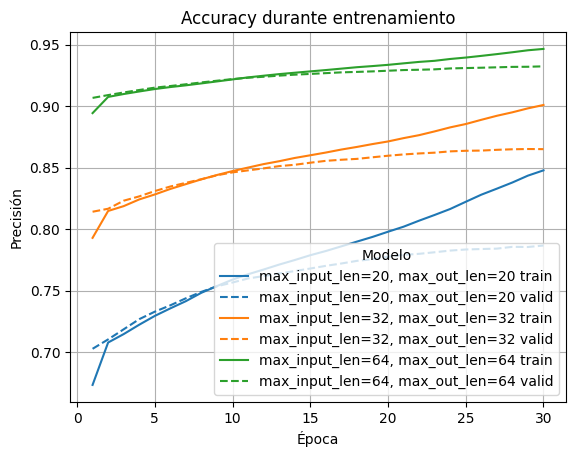

Tiempos de entrenamiento:
max_input_len=20, max_out_len=20: 214.16 segundos
max_input_len=32, max_out_len=32: 262.01 segundos
max_input_len=64, max_out_len=64: 416.78 segundos


In [16]:
plot_multiple_models(histories_lens, labels_lens)
print("Tiempos de entrenamiento:")
for label, time_taken in zip(labels_lens, time_taken_list_lens):
    print(f"{label}: {time_taken:.2f} segundos")

En el caso de la longitud de las secuencias, se observa un aumento considerable de la precisión al aumentar progresivamente la misma. En función de los resultados, resulta conveniente utilizar longitudes de 64, si el hardware de entrenamiento disponible lo permite.

In [17]:
# Modificamos el número de unidades en la LSTM para comparar su efecto en el rendimiento del modelo
histories_units = []
labels_units = []
time_taken_list_units = []
for n_units in [64, 128, 256, 512]:
    print(f"Entrenando modelo con n_units={n_units}...")
    model, hist, time_taken = build_model(n_units=n_units, epochs=30, plot=False)
    histories_units.append(hist)
    labels_units.append(f"n_units={n_units}")
    time_taken_list_units.append(time_taken)

Entrenando modelo con n_units=64...
Oraciones cargadas: 20000
Vocabulario EN: 6812 | ES: 11323
max_input_len=32  max_out_len=32
gloveembedding.pkl ya disponible.
Embeddings nulos: 306
Epoch 1/30


/home/jiteich/repos/ceia/pln1/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


    249/Unknown 6s 24ms/step - accuracy: 0.7465 - loss: 6.1162

I0000 00:00:1782093088.698173 2551226 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 18290802461504515207
I0000 00:00:1782093088.698200 2551226 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 14732368380969189672
/home/jiteich/repos/ceia/pln1/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.7722 - loss: 3.7162 - val_accuracy: 0.7779 - val_loss: 1.5651 - learning_rate: 5.0000e-04
Epoch 2/30
  7/250 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7857 - loss: 1.5111

...

I0000 00:00:1782094115.045577 2572608 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3173365102329996053
I0000 00:00:1782094115.045594 2572608 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 4569380834600027145
I0000 00:00:1782094115.045598 2572608 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 1989180100818665696
I0000 00:00:1782094115.045600 2572608 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 11356862021292535026
I0000 00:00:1782094115.045601 2572608 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3061796174163642220


249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9256 - loss: 0.3363

I0000 00:00:1782094124.032923 2572368 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 9193475964318917573


250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.9264 - loss: 0.3331 - val_accuracy: 0.8690 - val_loss: 0.8654 - learning_rate: 6.2500e-05
Restoring model weights from the end of the best epoch: 29.


I0000 00:00:1782094125.527492 2572608 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3173365102329996053
I0000 00:00:1782094125.527509 2572608 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 4569380834600027145
I0000 00:00:1782094125.527522 2572608 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 1989180100818665696
I0000 00:00:1782094125.527525 2572608 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 11356862021292535026
I0000 00:00:1782094125.527527 2572608 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3061796174163642220


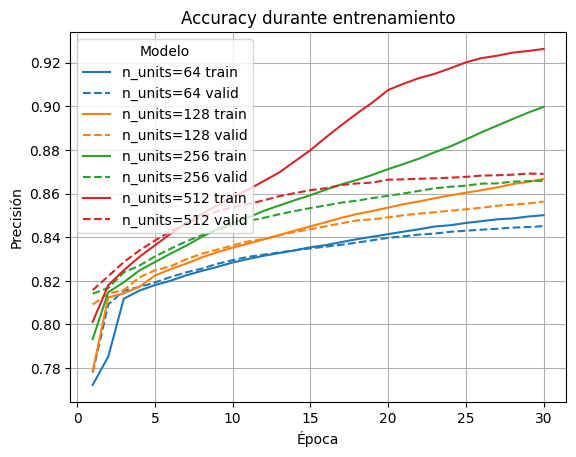

Tiempos de entrenamiento:
n_units=64: 220.85 segundos
n_units=128: 228.35 segundos
n_units=256: 286.71 segundos
n_units=512: 304.77 segundos


In [18]:
plot_multiple_models(histories_units, labels_units)
print("Tiempos de entrenamiento:")
for label, time_taken in zip(labels_units, time_taken_list_units):
    print(f"{label}: {time_taken:.2f} segundos")

Para la cantidad de unidades de las capas LSTM, se observa una ganancia al aumentar la cantidad de unidades, aunque marginal comparada a otros parámetros. Se decide utilizar 256 unidades, dado que se obtiene una precisión similar a 512 con una leve reducción del costo computacional.

Definimos entonces el mejor modelo según lo analizado con:
- Máximo tamaño del vocabulario (`MAX_VOCAB_SIZE`) = 32000
- Máxima cantidad de oraciones (`MAX_NUM_SENTENCES`) = 40000
- Máxima longitud de entrada (`max_input_len`) = 32
- Máxima longitud de salida (`max_output_len`) = 32
- Cantidad de unidades en las capas LSTM (`n_units`) = 512

Adicionalmente evaluamos como el modelo evoluciona al aumentar la cantidad de épocas de entrenamiento.

In [ ]:
MAX_VOCAB_SIZE = 32000
MAX_NUM_SENTENCES = 40000
max_input_len = 32
max_output_len = 32
n_units = 512

BATCH_SIZE = 64
val_split = 0.15
EMBED_DIM = 50

input_sentences, output_sentences, output_sentences_inputs = download_data(MAX_NUM_SENTENCES=MAX_NUM_SENTENCES)
num_words_output, encoder_input_sequences, decoder_input_sequences, \
decoder_output_sequences, word2idx_inputs, word2idx_outputs = tokenizer(
    MAX_VOCAB_SIZE=MAX_VOCAB_SIZE,
    max_input_len=max_input_len,
    max_out_len=max_output_len,
    input_sentences=input_sentences,
    output_sentences=output_sentences,
    output_sentences_inputs=output_sentences_inputs,    
)
nb_words, embedding_matrix = make_embeddings(MAX_VOCAB_SIZE, word2idx_inputs)
train_ds, val_ds = train_test_split(BATCH_SIZE, val_split, encoder_input_sequences, decoder_input_sequences, decoder_output_sequences, num_words_output)
enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
    nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units
)
dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
    num_words_output, max_output_len, n_units, enc_states
)

epochs_list = [20, 30, 50, 70]
epoch_models = {}
for epoch in epochs_list:
    model, encoder_model, decoder_model, hist, time_taken = compile_and_fit_model(n_units, nb_words, EMBED_DIM, embedding_matrix, max_input_len, num_words_output, max_output_len, train_ds, val_ds, epoch, return_enc_dec=True)
    epoch_models[epoch] = {
        "model": model,
        "encoder_model": encoder_model,
        "decoder_model": decoder_model,
        "history": hist,
        "time_taken": time_taken
    }

Oraciones cargadas: 40000
Vocabulario EN: 9120 | ES: 16144
max_input_len=32  max_out_len=32
gloveembedding.pkl ya disponible.
Embeddings nulos: 473
Epoch 1/20
    532/Unknown 26s 48ms/step - accuracy: 0.7897 - loss: 2.1761

I0000 00:00:1782094220.609466 2581574 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 11797339800094310461
I0000 00:00:1782094220.609489 2581574 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 9193475964318917573


532/532 ━━━━━━━━━━━━━━━━━━━━ 30s 55ms/step - accuracy: 0.8093 - loss: 1.5075 - val_accuracy: 0.8203 - val_loss: 1.2513 - learning_rate: 5.0000e-04
Epoch 2/20
  1/532 ━━━━━━━━━━━━━━━━━━━━ 42s 80ms/step - accuracy: 0.8330 - loss: 1.1524

I0000 00:00:1782094224.101803 2582263 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3173365102329996053
I0000 00:00:1782094224.101825 2582263 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 4569380834600027145
I0000 00:00:1782094224.101826 2582263 local_rendezvous.cc:436] Local rendezvous send item cancelled. Key hash: 12697049418492030559
I0000 00:00:1782094224.101829 2582263 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 1989180100818665696
I0000 00:00:1782094224.101831 2582263 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 11356862021292535026
I0000 00:00:1782094224.101834 2582263 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3061796174163642220


532/532 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8251 - loss: 1.1981

...

I0000 00:00:1782096900.791235 2602916 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3173365102329996053
I0000 00:00:1782096900.791255 2602916 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 4569380834600027145
I0000 00:00:1782096900.791257 2602916 local_rendezvous.cc:436] Local rendezvous send item cancelled. Key hash: 12697049418492030559
I0000 00:00:1782096900.791271 2602916 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 1989180100818665696
I0000 00:00:1782096900.791273 2602916 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 11356862021292535026
I0000 00:00:1782096900.791276 2602916 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3061796174163642220


531/532 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9387 - loss: 0.2609

I0000 00:00:1782096924.825827 2602329 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 9193475964318917573



Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
532/532 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - accuracy: 0.9398 - loss: 0.2568 - val_accuracy: 0.8861 - val_loss: 0.7270 - learning_rate: 2.5000e-04
Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 18.


I0000 00:00:1782096927.931332 2602916 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3173365102329996053
I0000 00:00:1782096927.931349 2602916 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 4569380834600027145
I0000 00:00:1782096927.931353 2602916 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 1989180100818665696
I0000 00:00:1782096927.931355 2602916 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 11356862021292535026
I0000 00:00:1782096927.931358 2602916 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3061796174163642220


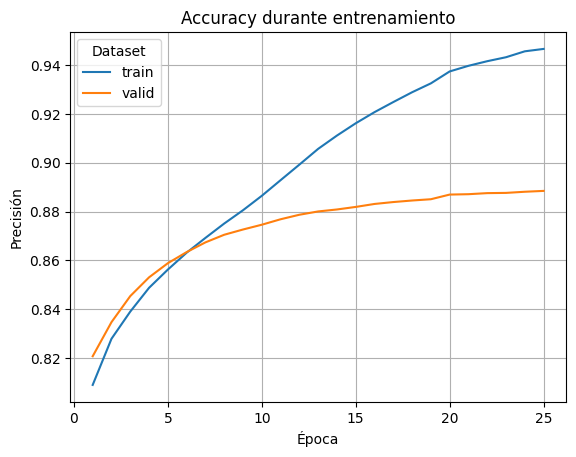

Tiempos de entrenamiento:
20 epochs: 572.12 segundos
30 epochs: 849.65 segundos
50 epochs: 683.56 segundos
70 epochs: 627.86 segundos


In [ ]:
print("Gráfico de precisión para el modelo entrenado durante 50 epochs")
plot_single_model(epoch_models[50]["history"])

print("Tiempos de entrenamiento:")
for label, time_taken in zip([f"{epoch} epochs" for epoch in epochs_list], [epoch_models[epoch]["time_taken"] for epoch in epochs_list]):
    print(f"{label}: {time_taken:.2f} segundos")

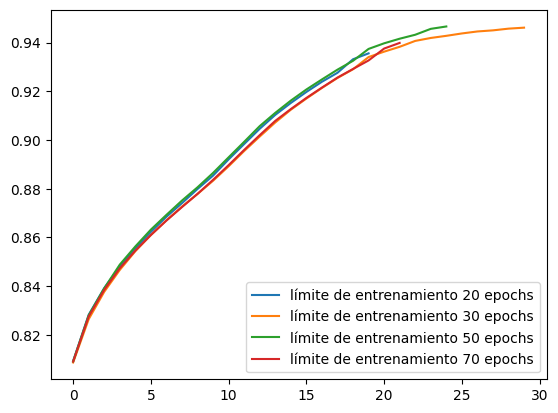

In [39]:
for hist, epochs in zip([epoch_models[epoch]["history"] for epoch in epochs_list], [epoch for epoch in epochs_list]):
    plt.plot(range(len(hist.history["accuracy"])), hist.history["accuracy"], label=f"límite de entrenamiento {epochs} epochs")
plt.legend()

Observamos que lso modelos con límite de 50 y 70 epochs, entrenaron hasta menos de 25 epochs debido a la condición de corte. El modelo que entrenó durante más epochs fue el de 30 epochs. EL modelo con mayor precisión fue el de 50 epochs.

Analicemos ahora la capacidad de traducción:

In [36]:
idx2word_input = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}
_, _, _, _, _, _, input_tokenizer = tokenizer(
    MAX_VOCAB_SIZE=MAX_VOCAB_SIZE,
    max_input_len=max_input_len,
    max_out_len=max_output_len,
    input_sentences=input_sentences,
    output_sentences=output_sentences,
    output_sentences_inputs=output_sentences_inputs,    
)

print("\n--- Ejemplos del dataset ---")
# np.random.set_state(42)
for _ in range(5):
    i = np.random.randint(len(input_sentences))
    seq = encoder_input_sequences[i : i + 1]
    print(f"EN: {input_sentences[i]}")
    print(f"ES (real): {output_sentences[i].replace(' <eos>', '')}")
    for epoch in epochs_list:
        pred = translate_sentence(seq, epoch_models[epoch]["encoder_model"], epoch_models[epoch]["decoder_model"], word2idx_outputs, idx2word_target, max_output_len)
        print(f"ES (pred, {epoch} epochs): {pred}")
    print("\n")

print("--- Frases nuevas ---")
for s in [
    "My mother says hi.",
    "Where is the train station?",
    "I love learning languages.",
    "Can you help me?",
    "Do you speak spanish?"
]:
    print(f"EN: {s}")
    for epoch in epochs_list:
        pred = translate(s, input_tokenizer, max_input_len, epoch_models[epoch]["encoder_model"], epoch_models[epoch]["decoder_model"], word2idx_outputs, idx2word_target, max_output_len)
        print(f"ES (pred, {epoch} epochs): {pred}")
    print("\n")


Vocabulario EN: 9120 | ES: 16144
max_input_len=32  max_out_len=32

--- Ejemplos del dataset ---
EN: Tom doesn't seem to be babbling.
ES (real): Tom no parece estar chismorreando.
ES (pred, 20 epochs): tom no parece estar chismorreando
ES (pred, 30 epochs): tom no parece estar chismorreando
ES (pred, 50 epochs): tom no parece estar chismorreando
ES (pred, 70 epochs): tom no parece estar chismorreando


EN: This isn't the first time this has happened.
ES (real): No es la primera vez que pasa esto.
ES (pred, 20 epochs): este libro no es lo mejor que ayer
ES (pred, 30 epochs): esta mañana no es lo que pasó aquel
ES (pred, 50 epochs): esta es la primera vez que lo ocurrido
ES (pred, 70 epochs): esta vez es la primera vez que he visto hasta esto


EN: Tom decided that he wanted to eat by himself.
ES (real): Tom decidió que quería comer solo.
ES (pred, 20 epochs): tom decidió que no le compremos algo
ES (pred, 30 epochs): tom decidió que no quería comer con mary
ES (pred, 50 epochs): tom deci

Se observa que en casos muy sencillos o muy específicos los modelos se comportan muy similar, pero en casos con más ambigüedad en la posibilidad de traducción, los modelos difieren bastante el uno del otro.